In [3]:
import dask
import cftime
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cmocean.cm as cmo

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import xclimate as xclim

# What LENS2 member best matches observations (e.g., ENSO phase) during the transition between historical and future periods?

In [4]:
client_cluster = xclim.create_dask_cluster(
    account='UWAS0155',
    nworkers=4,
    ncores=1,
    nmem='15GB',
    walltime='02:00:00'
)

account:  UWAS0155
nworkers: 4
ncores:   1
nmemory:  15GB
walltime: 02:00:00


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 42053 instead
  warnings.warn(


{'PBSCluster-1': <dask_jobqueue.pbs.PBSJob: status=running>, 'PBSCluster-0': <dask_jobqueue.pbs.PBSJob: status=running>, 'PBSCluster-3': <dask_jobqueue.pbs.PBSJob: status=running>, 'PBSCluster-2': <dask_jobqueue.pbs.PBSJob: status=running>}

To view the dask dashboard
Run the following command in your local terminal:
> ssh -N -L 42053:128.117.211.162:42053 bbuchovecky@casper.hpc.ucar.edu
Open the following link in your local browser:
> http://localhost:42053/status


In [9]:
# client_cluster[1]

In [114]:
xclim.close_dask_cluster(client_cluster)

# full time period

In [5]:
tperiod = slice('2001-01', '2021-12')

# masks

In [6]:
ds = xr.open_dataset('/glade/campaign/collections/gdex/data/d651056/CESM2-LE/atm/proc/tseries/month_1/AREA/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h0.AREA.195001-195912.nc')
area = ds.AREA.isel(time=0).drop_vars('time')

ds = xr.open_dataset('/glade/campaign/collections/gdex/data/d651056/CESM2-LE/lnd/proc/tseries/month_1/GPP/b.e21.BHISTcmip6.f09_g17.LE2-1301.006.clm2.h2.GPP.195001-195912.nc')
ds = ds.reindex_like(area, tolerance=1e-3, method='nearest').drop_vars('time')
a = (ds.area * 1e6).assign_attrs({'units': 'm2'})
lf = ds.landfrac
la = a * lf
lm = ~np.isnan(la)
om = ~lm
oa = area.where(om, other=0)

# load HadOI

In [7]:
hadbc = xr.open_dataset('/glade/campaign/cesm/cesmdata/inputdata/atm/cam/sst/sst_HadOIBl_bc_0.9x1.25_1850_2022_c241003.nc')
obs = hadbc.SST_cpl_prediddle.sel(time=tperiod).reindex_like(area, tolerance=1e-3, method='nearest')

# load LENS2

In [10]:
from glob import glob

xr.set_options(use_new_combine_kwarg_defaults=True)

v   = 'SST'
bb  = 'cmip6'
lens_dir = '/glade/campaign/collections/gdex/data/d651056/CESM2-LE/atm/proc/tseries/month_1'
lens_starts = [
    '1001', '1021', '1041', '1061', '1081', '1101', '1121',
    '1141', '1161', '1181', '1231', '1251', '1281', '1301'
]

def load_member(yr: str, mem_str: str) -> xr.DataArray:
    """Open, time-concat, reindex, and mask one ensemble member."""
    files = sorted(
        glob(f'{lens_dir}/{v}/b.e21.BHIST{bb}.f09_g17.LE2-{yr}.{mem_str}.cam.h0.{v}.*.nc') +
        glob(f'{lens_dir}/{v}/b.e21.BSSP370{bb}.f09_g17.LE2-{yr}.{mem_str}.cam.h0.{v}.*.nc')
    )
    ds = xr.open_mfdataset(
        files,
        parallel=True,
        combine='by_coords',
        data_vars='minimal',
        coords='minimal',
        compat='override',
    )
    return (
        xclim.time_coord.shift_time(ds)
        .sel(time=tperiod)[v]
        .where(om)
    )

members = []
for im, yr in enumerate(lens_starts):
    print(f'- {yr}')
    if int(yr) < 1200:
        members.append(load_member(yr, str(im + 1).zfill(3)))
    else:
        for i in range(1, 11):
            print(str(i).zfill(3), end=' ')
            members.append(load_member(yr, str(i).zfill(3)))
        print()

lens = (
    xr.concat(members, dim='ens')
    .assign_coords(ens=np.arange(1, 51))
    .assign_attrs(units='deg_C')
    - 273.15
)
lens = lens.chunk({'time': -1}).persist()

- 1001
- 1021
- 1041
- 1061
- 1081
- 1101
- 1121
- 1141
- 1161
- 1181
- 1231
001 002 003 004 005 006 007 008 009 010 
- 1251
001 002 003 004 005 006 007 008 009 010 
- 1281
001 002 003 004 005 006 007 008 009 010 
- 1301
001 002 003 004 005 006 007 008 009 010 


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 9.68 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [ ]:
# mlens = lens.mean(dim='ens').chunk(time=1)
# mlens.to_netcdf('/glade/campaign/univ/uwas0155/ppe/docn_sst/b.e21.cmip6.f09_g17.LE2-ens-mean.cam.h0.SST.198001-202112.nc')

# compute gridcell-level SST error metrics

In [62]:
t0 = '2014-12'
t1 = '2015-01'

# obs_dt = obs.sel(time=t1).isel(time=0, drop=True) - obs.sel(time=t0).isel(time=0, drop=True)
# lens_dt = lens.sel(time=t1).isel(time=0, drop=True) - lens.sel(time=t0).isel(time=0, drop=True)

obs_dt = obs.sel(time=t0).isel(time=0, drop=True)
lens_dt = lens.sel(time=t0).isel(time=0, drop=True)

dt_mae_area = np.abs(lens_dt - obs_dt).weighted(oa).mean(dim=['lat', 'lon']).compute()
dt_mse_area = ((lens_dt - obs_dt) ** 2).weighted(oa).mean(dim=['lat', 'lon']).compute()
dt_rmse_area = np.sqrt((lens_dt - obs_dt) ** 2).weighted(oa).mean(dim=['lat', 'lon']).compute()

Text(0.5, 1.0, '2015-01$-$2014-12 SST RMSE')

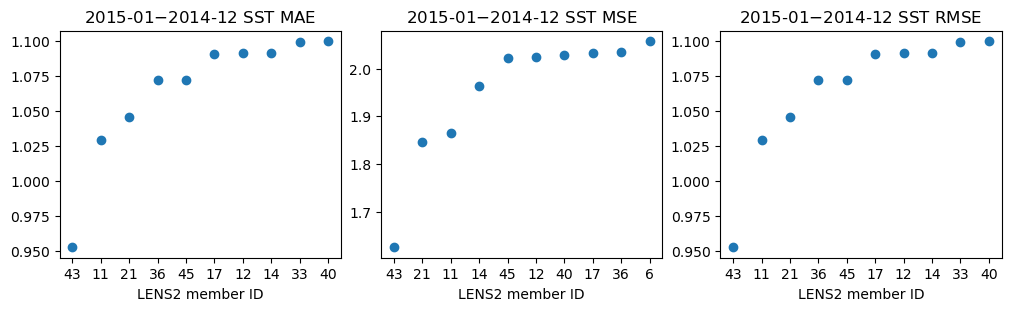

In [63]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3), sharey=False, layout='constrained')

for i, error in enumerate([dt_mae_area, dt_mse_area, dt_rmse_area]):
    error.sortby(error).assign_coords(ens=np.arange(50))[:10].plot(ax=ax[i], marker='o', lw=0)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('LENS2 member ID')
    ax[i].set_xticks(np.arange(50)[:10])
    ax[i].set_xticklabels(error.ens.sortby(error).data[:10]);

ax[0].set_title('2015-01$-$2014-12 SST MAE')
ax[1].set_title('2015-01$-$2014-12 SST MSE')
ax[2].set_title('2015-01$-$2014-12 SST RMSE')

In [64]:
tslice = slice('2014-06', '2015-05')
t = obs.sel(time=tslice).time.compute()

delta = lens.sel(time=tslice).assign_coords(time=t).compute() - obs.sel(time=tslice).compute()

sst_mae = np.abs(delta).weighted(oa).mean(dim=['time']).compute()
sst_mse = (delta ** 2).weighted(oa).mean(dim=['time']).compute()
sst_rmse = np.sqrt(delta ** 2).weighted(oa).mean(dim=['time']).compute()

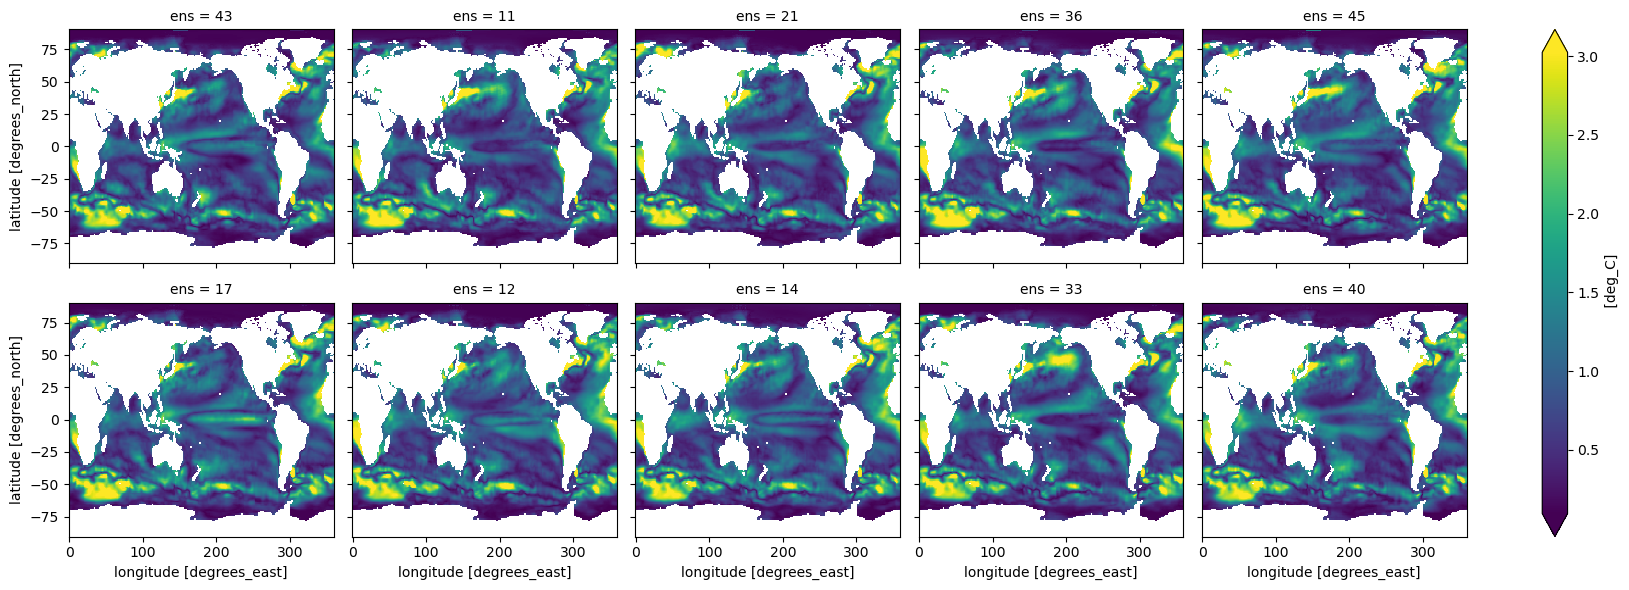

In [67]:
sst_rmse.sortby(dt_rmse_area)[:10].plot(col='ens', col_wrap=5, robust=True, cbar_kwargs={'fraction': 0.025})

# compute NINO3.4

In [16]:
def compute_nino34_rolling_reference(sst, area, rolling_nmonths=5):
    '''
    "Nino X Index computation: (a) Compute area averaged total SST from Niño X region; (b) Compute monthly climatology
    (e.g., 1950-1979) for area averaged total SST from Niño X region, and subtract climatology from area averaged total
    SST time series to obtain anomalies; (c) Smooth the anomalies with a 5-month running mean; (d) Normalize the smoothed
    values by its standard deviation over the climatological period."
    https://climatedataguide.ucar.edu/climate-data/nino-sst-indices-nino-12-3-34-4-oni-and-tni#:~:text=Technical%20Notes
    '''
    sst_nino34 = sst.sel(lat=slice(-5, 5), lon=slice(190, 240))
    sst_nino34_ts = sst_nino34.weighted(area).mean(dim=['lat', 'lon'])

    sst_nino34_base_mean = (
        sst_nino34_ts
        .groupby('time.month')
        .map(lambda x: x.rolling(time=30, center=True).mean().ffill('time').bfill('time'))
    )
    sst_nino34_base_std = (
        sst_nino34_ts
        .groupby('time.month')
        .map(lambda x: x.rolling(time=30, center=True).std().ffill('time').bfill('time'))
    )

    sst_nino34_anom_mean_norm = (sst_nino34_ts - sst_nino34_base_mean) / sst_nino34_base_std

    nino34 = sst_nino34_anom_mean_norm.rolling(time=rolling_nmonths, center=True).mean()

    return nino34


def plot_nino34(nino34):
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)

    ax.fill_between(
        nino34.time.data,
        nino34.where(nino34 >= 0.5).data,
        0.5,
        color = "red",
        alpha = 0.9,
    )
    ax.fill_between(
        nino34.time.data,
        nino34.where(nino34 <= -0.5).data,
        -0.5,
        color = "blue",
        alpha = 0.9,
    )

    nino34.plot(color="black", lw=0.8)
    ax.axhline(0, color="black", lw = 0.5)
    ax.axhline(0.5, color="black", linewidth = 0.5, linestyle="dotted") 
    ax.axhline(-0.5, color="black", linewidth = 0.5, linestyle="dotted")

    ax.set_title(f"NINO 3.4 Index")
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("SST Anomalies (°C)")

    return fig, ax

In [9]:
lens_nino34 = compute_nino34_rolling_reference(lens, area.where(om, other=0))
obs_nino34 = compute_nino34_rolling_reference(obs, area.where(om, other=0))

In [10]:
lens_nino34 = lens_nino34.compute()
obs_nino34 = obs_nino34.compute()

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

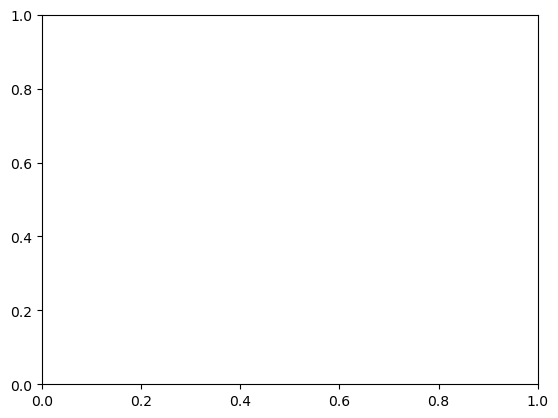

In [17]:
fig, ax = plot_nino34(obs_nino34.sel(time=slice('2013', '2017')))
for i in range(50):
    lens_nino34.sel(time=slice('2014', '2016')).isel(ens=i).plot(ax=ax, c='gray', lw=0.5)

# compute NINO3.4 error metrics

nested time periods for selection of "best" ensemble member --> first screen over longer 10-year period from 2010-2020, then select final member based on 2014-2015 branch year

In [11]:
diff_nino34 = obs_nino34 - lens_nino34.assign_coords(time=obs_nino34.time)  # simple fix for time discrepancy between start vs. midpoints of months

error_long_tperiod = slice('2009', '2020')
error_short_tperiod = slice('2014', '2015')

mae_long = np.abs(diff_nino34.sel(time=error_long_tperiod)).mean(dim='time')
mse_long = (diff_nino34.sel(time=error_long_tperiod) ** 2).mean(dim='time')
rmse_long = np.sqrt((diff_nino34.sel(time=error_long_tperiod) ** 2).mean(dim='time'))

mae_short = np.abs(diff_nino34.sel(time=error_short_tperiod)).mean(dim='time')
mse_short = (diff_nino34.sel(time=error_short_tperiod) ** 2).mean(dim='time')
rmse_short = np.sqrt((diff_nino34.sel(time=error_short_tperiod) ** 2).mean(dim='time'))

Text(0, 0.5, 'MAE [deg_C]')

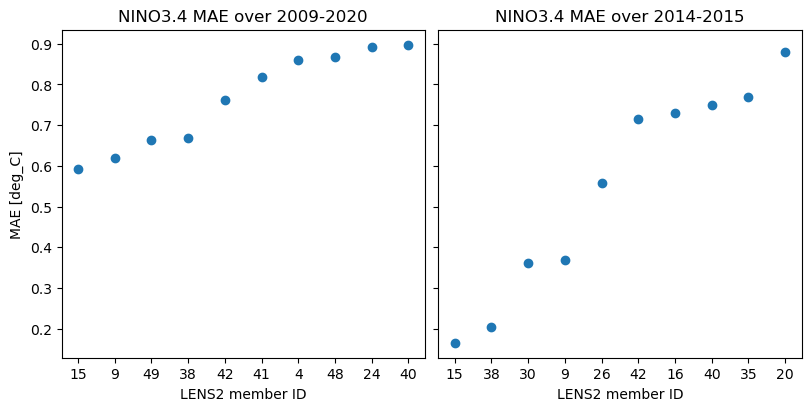

In [84]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True, layout='constrained')

for i, error in enumerate([mae_long, mae_short]):
    error.sortby(error).assign_coords(ens=np.arange(50))[:10].plot(ax=ax[i], marker='o', lw=0)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('LENS2 member ID')
    ax[i].set_xticks(np.arange(50)[:10])
    ax[i].set_xticklabels(error.ens.sortby(error).data[:10]);

ax[0].set_title(f"NINO3.4 MAE over {error_long_tperiod.start}-{error_long_tperiod.stop}")
ax[1].set_title(f"NINO3.4 MAE over {error_short_tperiod.start}-{error_short_tperiod.stop}")
ax[0].set_ylabel("MAE [deg_C]")

Text(0, 0.5, 'MSE [deg_C^2]')

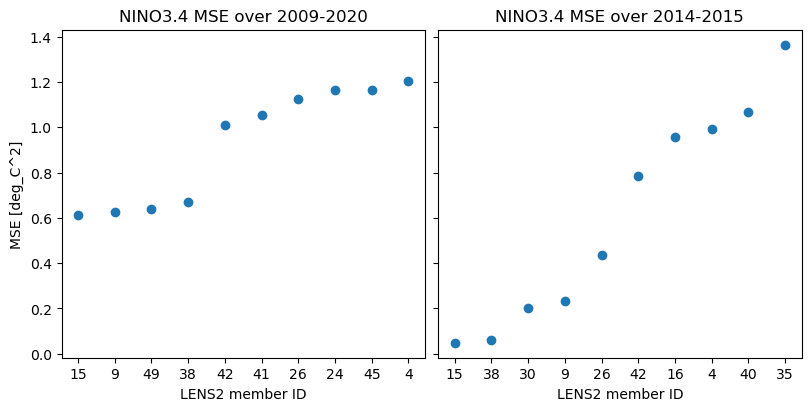

In [85]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True, layout='constrained')

for i, error in enumerate([mse_long, mse_short]):
    error.sortby(error).assign_coords(ens=np.arange(50))[:10].plot(ax=ax[i], marker='o', lw=0)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('LENS2 member ID')
    ax[i].set_xticks(np.arange(50)[:10])
    ax[i].set_xticklabels(error.ens.sortby(error).data[:10]);

ax[0].set_title(f"NINO3.4 MSE over {error_long_tperiod.start}-{error_long_tperiod.stop}")
ax[1].set_title(f"NINO3.4 MSE over {error_short_tperiod.start}-{error_short_tperiod.stop}")
ax[0].set_ylabel("MSE [deg_C^2]")

Text(0, 0.5, 'RMSE [deg_C]')

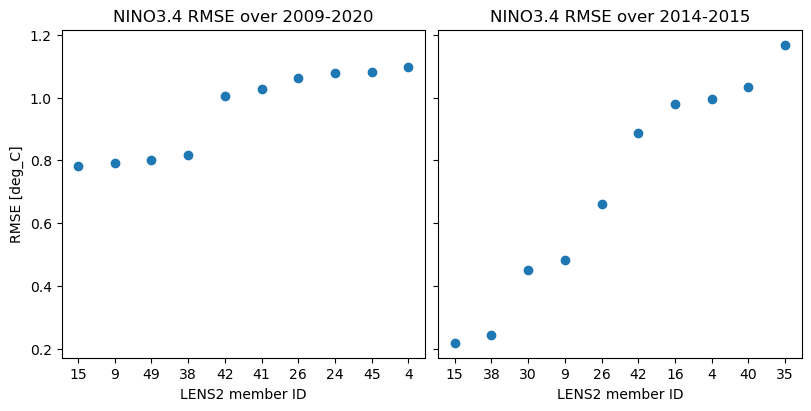

In [86]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True, layout='constrained')

for i, error in enumerate([rmse_long, rmse_short]):
    error.sortby(error).assign_coords(ens=np.arange(50))[:10].plot(ax=ax[i], marker='o', lw=0)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('LENS2 member ID')
    ax[i].set_xticks(np.arange(50)[:10])
    ax[i].set_xticklabels(error.ens.sortby(error).data[:10]);

ax[0].set_title(f"NINO3.4 RMSE over {error_long_tperiod.start}-{error_long_tperiod.stop}")
ax[1].set_title(f"NINO3.4 RMSE over {error_short_tperiod.start}-{error_short_tperiod.stop}")
ax[0].set_ylabel("RMSE [deg_C]")

Text(0.5, 0.98, 'NINO3.4, members ranked by MAE over 2009-2020')

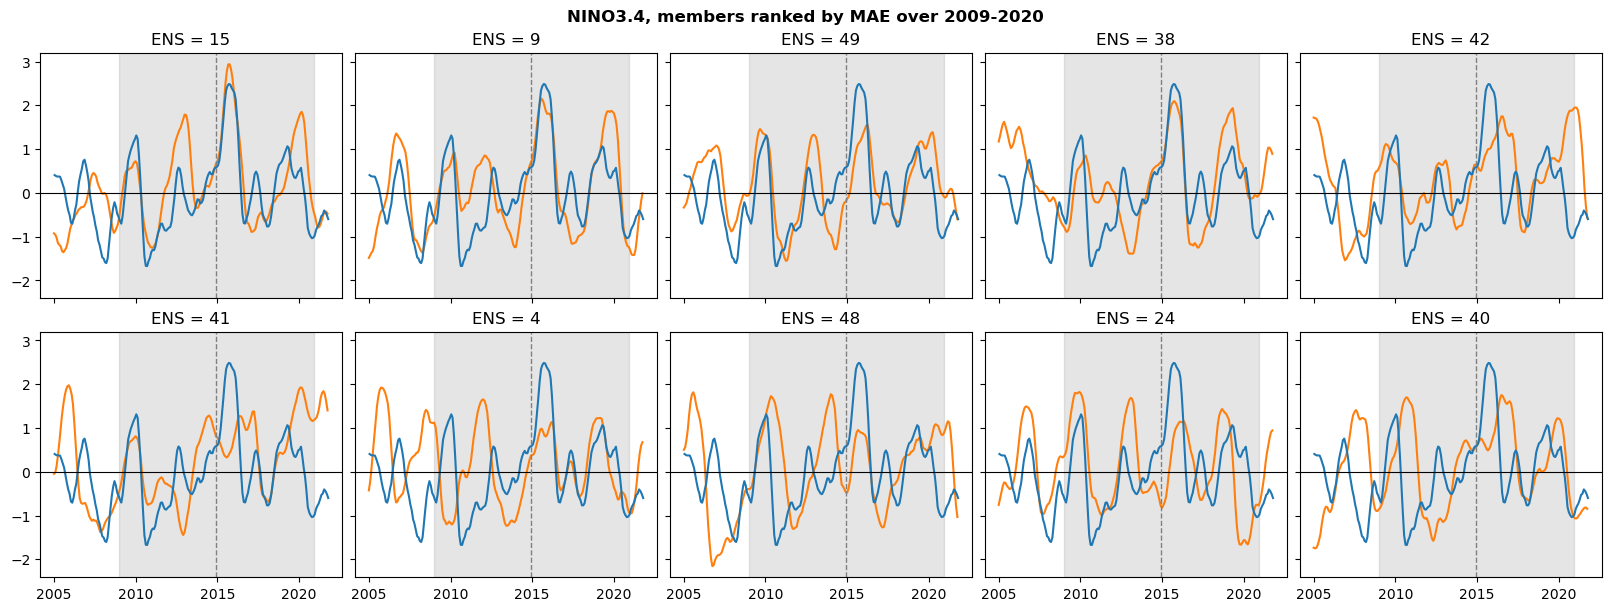

In [81]:
period = error_long_tperiod
error = mae_long

fg = lens_nino34.sortby(error).sel(time=slice('2005', '2021')).isel(ens=slice(0, 10)).plot(col='ens', col_wrap=5, c='tab:orange')
for i, ax in enumerate(fg.axs.flatten()):
    obs_nino34.sel(time=slice('2005', '2021')).plot(ax=ax, c='tab:blue')
    ax.axhline(0, lw=0.8, c='k')
    # ax.axvline(cftime.DatetimeGregorian(int(period.start), 1, 1), color='gray', lw=1, ls='--')
    # ax.axvline(cftime.DatetimeGregorian(int(period.stop), 12, 1), color='gray', lw=1, ls='--')
    ax.axvline(cftime.DatetimeGregorian(2014, 12, 1), color='gray', lw=1, ls='--')
    ax.axvspan(
        cftime.DatetimeGregorian(int(period.start), 1, 1),
        cftime.DatetimeGregorian(int(period.stop), 12, 1),
        color='gray',
        alpha=0.2,
    )
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(f'ENS = {lens_nino34.sortby(error).ens.isel(ens=i).data}')

fg.fig.set_layout_engine('constrained')
fg.fig.suptitle(f"NINO3.4, members ranked by MAE over {period.start}-{period.stop}", fontweight='bold')

Text(0.5, 0.98, 'NINO3.4, members ranked by MAE over 2014-2015')

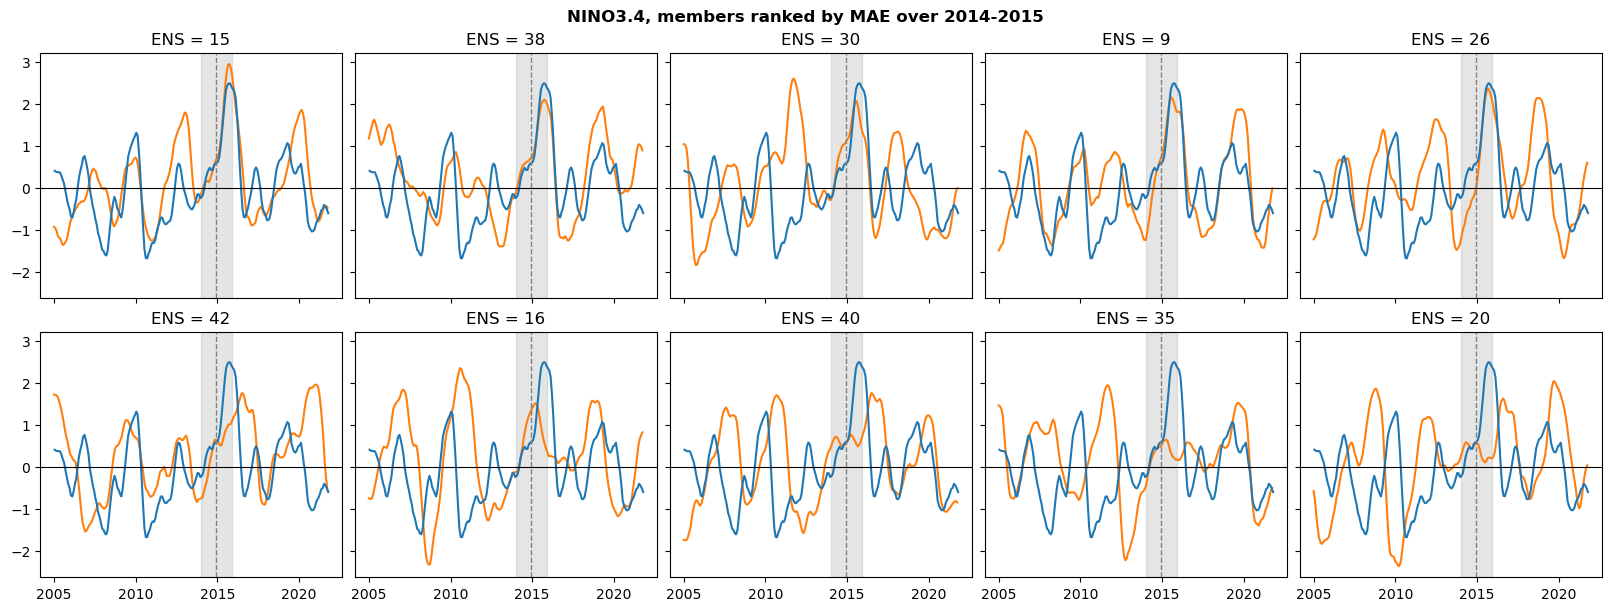

In [82]:
period = error_short_tperiod
error = mae_short

fg = lens_nino34.sortby(error).sel(time=slice('2005', '2021')).isel(ens=slice(0, 10)).plot(col='ens', col_wrap=5, c='tab:orange')
for i, ax in enumerate(fg.axs.flatten()):
    obs_nino34.sel(time=slice('2005', '2021')).plot(ax=ax, c='tab:blue')
    ax.axhline(0, lw=0.8, c='k')
    # ax.axvline(cftime.DatetimeGregorian(int(period.start), 1, 1), color='gray', lw=1, ls='--')
    # ax.axvline(cftime.DatetimeGregorian(int(period.stop), 12, 1), color='gray', lw=1, ls='--')
    ax.axvline(cftime.DatetimeGregorian(2014, 12, 1), color='gray', lw=1, ls='--')
    ax.axvspan(
        cftime.DatetimeGregorian(int(period.start), 1, 1),
        cftime.DatetimeGregorian(int(period.stop), 12, 1),
        color='gray',
        alpha=0.2,
    )
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(f'ENS = {lens_nino34.sortby(error).ens.isel(ens=i).data}')

fg.fig.set_layout_engine('constrained')
fg.fig.suptitle(f"NINO3.4, members ranked by MAE over {period.start}-{period.stop}", fontweight='bold')

Text(0.5, 0.98, 'NINO3.4, members ranked by MSE over 2009-2020')

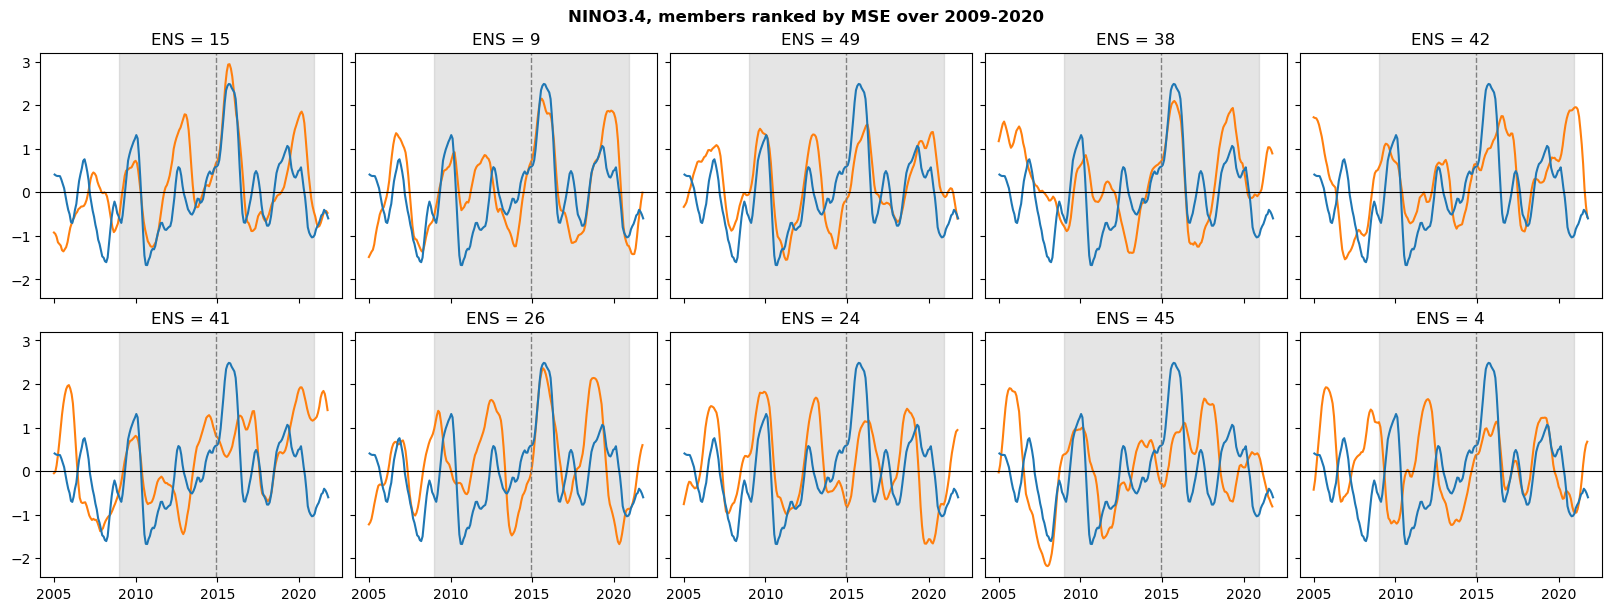

In [78]:
period = error_long_tperiod
error = mse_long

fg = lens_nino34.sortby(error).sel(time=slice('2005', '2021')).isel(ens=slice(0, 10)).plot(col='ens', col_wrap=5, c='tab:orange')
for i, ax in enumerate(fg.axs.flatten()):
    obs_nino34.sel(time=slice('2005', '2021')).plot(ax=ax, c='tab:blue')
    ax.axhline(0, lw=0.8, c='k')
    # ax.axvline(cftime.DatetimeGregorian(int(period.start), 1, 1), color='gray', lw=1, ls='--')
    # ax.axvline(cftime.DatetimeGregorian(int(period.stop), 12, 1), color='gray', lw=1, ls='--')
    ax.axvline(cftime.DatetimeGregorian(2014, 12, 1), color='gray', lw=1, ls='--')
    ax.axvspan(
        cftime.DatetimeGregorian(int(period.start), 1, 1),
        cftime.DatetimeGregorian(int(period.stop), 12, 1),
        color='gray',
        alpha=0.2,
    )
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(f'ENS = {lens_nino34.sortby(error).ens.isel(ens=i).data}')

fg.fig.set_layout_engine('constrained')
fg.fig.suptitle(f"NINO3.4, members ranked by MSE over {period.start}-{period.stop}", fontweight='bold')

Text(0.5, 0.98, 'NINO3.4, members ranked by MSE over 2014-2015')

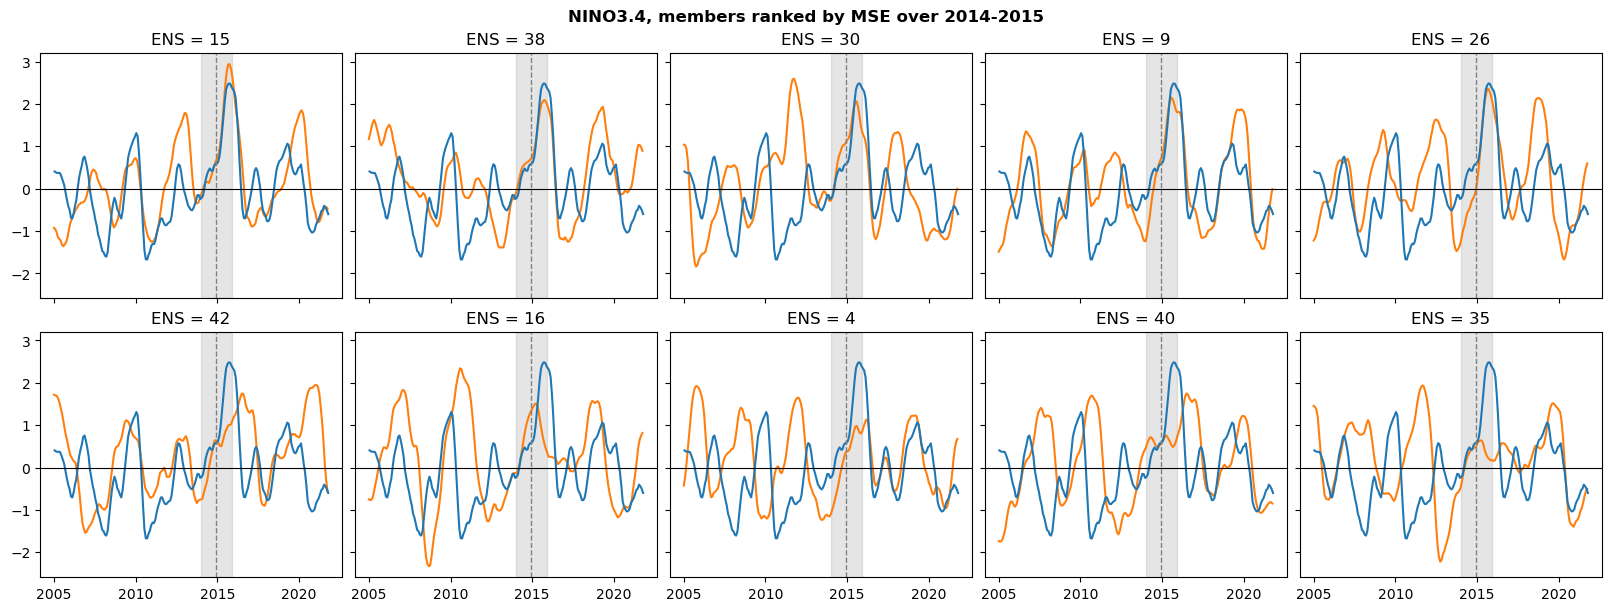

In [79]:
period = error_short_tperiod
error = mse_short

fg = lens_nino34.sortby(error).sel(time=slice('2005', '2021')).isel(ens=slice(0, 10)).plot(col='ens', col_wrap=5, c='tab:orange')
for i, ax in enumerate(fg.axs.flatten()):
    obs_nino34.sel(time=slice('2005', '2021')).plot(ax=ax, c='tab:blue')
    ax.axhline(0, lw=0.8, c='k')
    # ax.axvline(cftime.DatetimeGregorian(int(period.start), 1, 1), color='gray', lw=1, ls='--')
    # ax.axvline(cftime.DatetimeGregorian(int(period.stop), 12, 1), color='gray', lw=1, ls='--')
    ax.axvline(cftime.DatetimeGregorian(2014, 12, 1), color='gray', lw=1, ls='--')
    ax.axvspan(
        cftime.DatetimeGregorian(int(period.start), 1, 1),
        cftime.DatetimeGregorian(int(period.stop), 12, 1),
        color='gray',
        alpha=0.2,
    )
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(f'ENS = {lens_nino34.sortby(error).ens.isel(ens=i).data}')

fg.fig.set_layout_engine('constrained')
fg.fig.suptitle(f"NINO3.4, members ranked by MSE over {period.start}-{period.stop}", fontweight='bold')

# compare regions for candidate members

In [71]:
candidates = [9, 15, 30]

In [72]:
sst_region_bnds = {
    'nat': [[47, 57], [315, 335]],
    'sep': [[-62, -47], [220, 290]],
    'nep': [[35, 50], [190, 220]],
    'npa': [[30, 50], [150, 230]],
    'ind': [[-15, 5], [60, 90]],
    'sop': [[-62, -47], [100, 140]],
    'so': [[-90, -50], [0, 360]],
}

sst_region_names = {
    'nat': 'N. Atlantic box',
    'sep': 'S. East Pacific box',
    'nep': 'N. East Pacific box',
    'npa': 'N. Pacific box',
    'ind': 'Indian Ocean box',
    'sop': 'Southern Ocean box',
    'so': 'Southern Ocean',
}

sst_regions = {}
for name, bnds in sst_region_bnds.items():
    lat_bnds = bnds[0]
    lon_bnds = bnds[1]
    reg = obs.isel(time=0).drop_vars('time')
    reg = ((reg.lat >= lat_bnds[0]) & (reg.lat < lat_bnds[1]) & (reg.lon >= lon_bnds[0]) & (reg.lon < lon_bnds[1]))
    sst_regions[name] = reg.where(om).rename(name)

N. Atlantic box annual stddev
  HadOI =  0.539
  LENS09 =  0.500
  LENS15 =  0.450
  LENS30 =  0.396
S. East Pacific box annual stddev
  HadOI =  0.235
  LENS09 =  0.295
  LENS15 =  0.411
  LENS30 =  0.284
N. East Pacific box annual stddev
  HadOI =  0.492
  LENS09 =  0.555
  LENS15 =  0.479
  LENS30 =  0.668
N. Pacific box annual stddev
  HadOI =  0.304
  LENS09 =  0.409
  LENS15 =  0.268
  LENS30 =  0.514
Indian Ocean box annual stddev
  HadOI =  0.180
  LENS09 =  0.283
  LENS15 =  0.331
  LENS30 =  0.218
Southern Ocean box annual stddev
  HadOI =  0.144
  LENS09 =  0.201
  LENS15 =  0.227
  LENS30 =  0.228
Southern Ocean annual stddev
  HadOI =  0.102
  LENS09 =  0.080
  LENS15 =  0.106
  LENS30 =  0.100


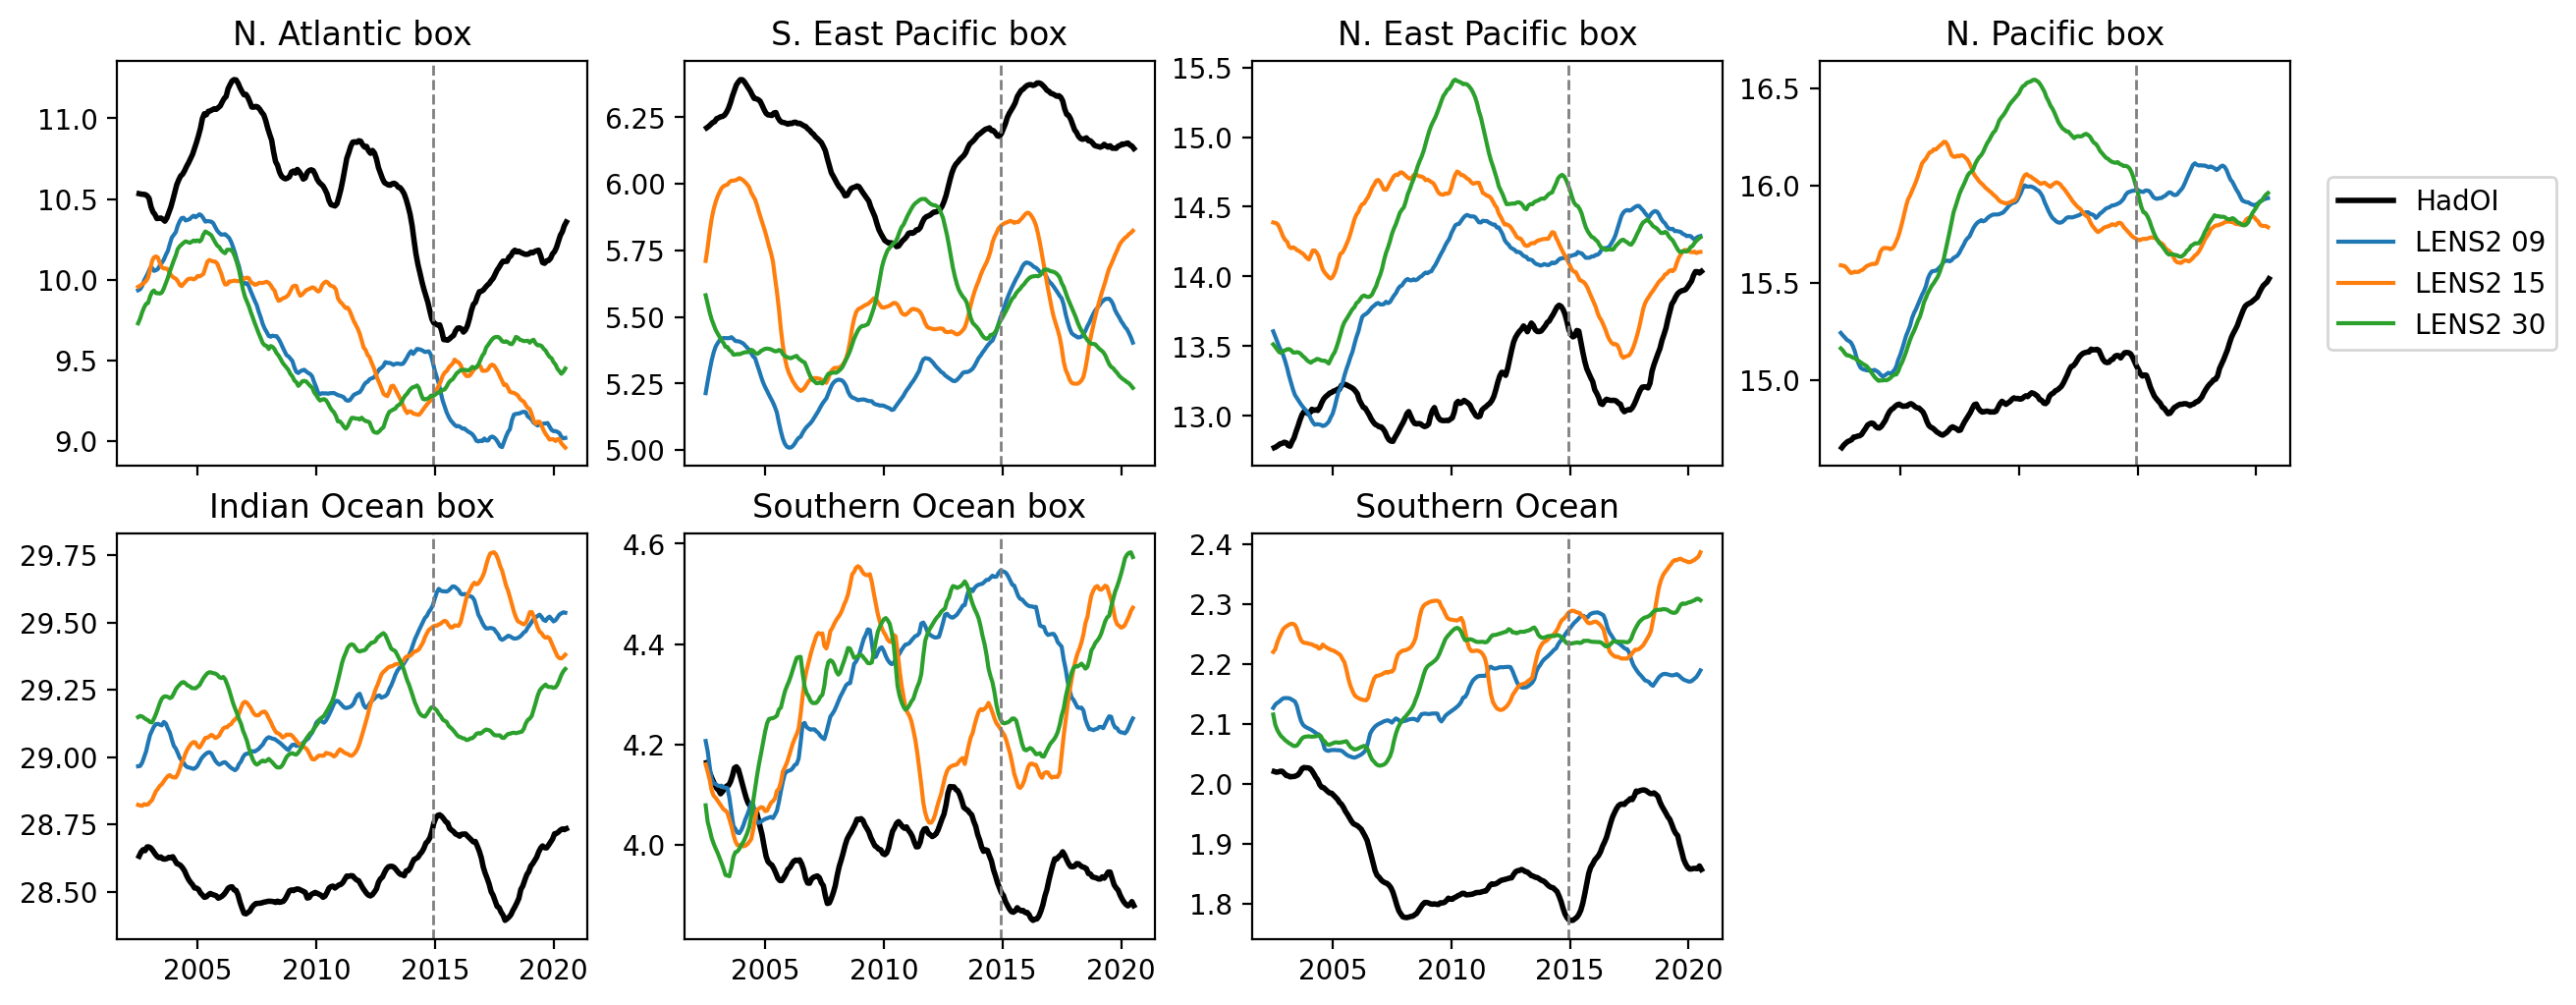

In [75]:
smooth_months = 36
tperiod = slice('1995-01', '2021-12')

fig, axs = plt.subplots(2, 4, figsize=(13, 5), sharex=True, layout='constrained', dpi=200)
ax = axs.flatten()

for i, (name, reg) in enumerate(sst_regions.items()):
    obs_reg_roll = obs.where(reg).sel(time=tperiod).weighted(oa).mean(dim=['lat', 'lon']).rolling(time=smooth_months, center=True).mean().compute()
    lens_reg_roll = lens.sel(ens=candidates).where(reg).sel(time=tperiod).weighted(oa).mean(dim=['lat', 'lon']).rolling(time=smooth_months, center=True).mean().compute()

    obs_reg_ann = obs.where(reg).weighted(oa).mean(dim=['lat', 'lon']).groupby('time.year').mean().compute()
    lens_reg_ann = lens.sel(ens=candidates).where(reg).weighted(oa).mean(dim=['lat', 'lon']).groupby('time.year').mean().compute()

    obs_reg_roll.plot(ax=ax[i], c='k', ls='-', lw=2, label='HadOI')
    for ens in candidates:
        lens_reg_roll.sel(ens=ens).plot(ax=ax[i], ls='-', label=f'LENS2 {str(ens).zfill(2)}')
    ax[i].axvline(cftime.DatetimeGregorian(2014, 12, 1), color='gray', lw=1, ls='--')
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_title(sst_region_names[name])

    print(sst_region_names[name], 'annual stddev')
    print(f'  HadOI = {obs_reg_ann.std(dim='year').values: 0.3f}')
    for ens in candidates:
        print(f'  LENS{str(ens).zfill(2)} = {lens_reg_ann.sel(ens=ens).std(dim='year').values: 0.3f}')

ax[3].legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
ax[-1].remove()

N. Atlantic box annual stddev
  HadOI =  0.539
  LENS09 =  0.500
  LENS15 =  0.450
  LENS30 =  0.396
S. East Pacific box annual stddev
  HadOI =  0.235
  LENS09 =  0.295
  LENS15 =  0.411
  LENS30 =  0.284
N. East Pacific box annual stddev
  HadOI =  0.492
  LENS09 =  0.555
  LENS15 =  0.479
  LENS30 =  0.668
N. Pacific box annual stddev
  HadOI =  0.304
  LENS09 =  0.409
  LENS15 =  0.268
  LENS30 =  0.514
Indian Ocean box annual stddev
  HadOI =  0.180
  LENS09 =  0.283
  LENS15 =  0.331
  LENS30 =  0.218
Southern Ocean box annual stddev
  HadOI =  0.144
  LENS09 =  0.201
  LENS15 =  0.227
  LENS30 =  0.228
Southern Ocean annual stddev
  HadOI =  0.102
  LENS09 =  0.080
  LENS15 =  0.106
  LENS30 =  0.100


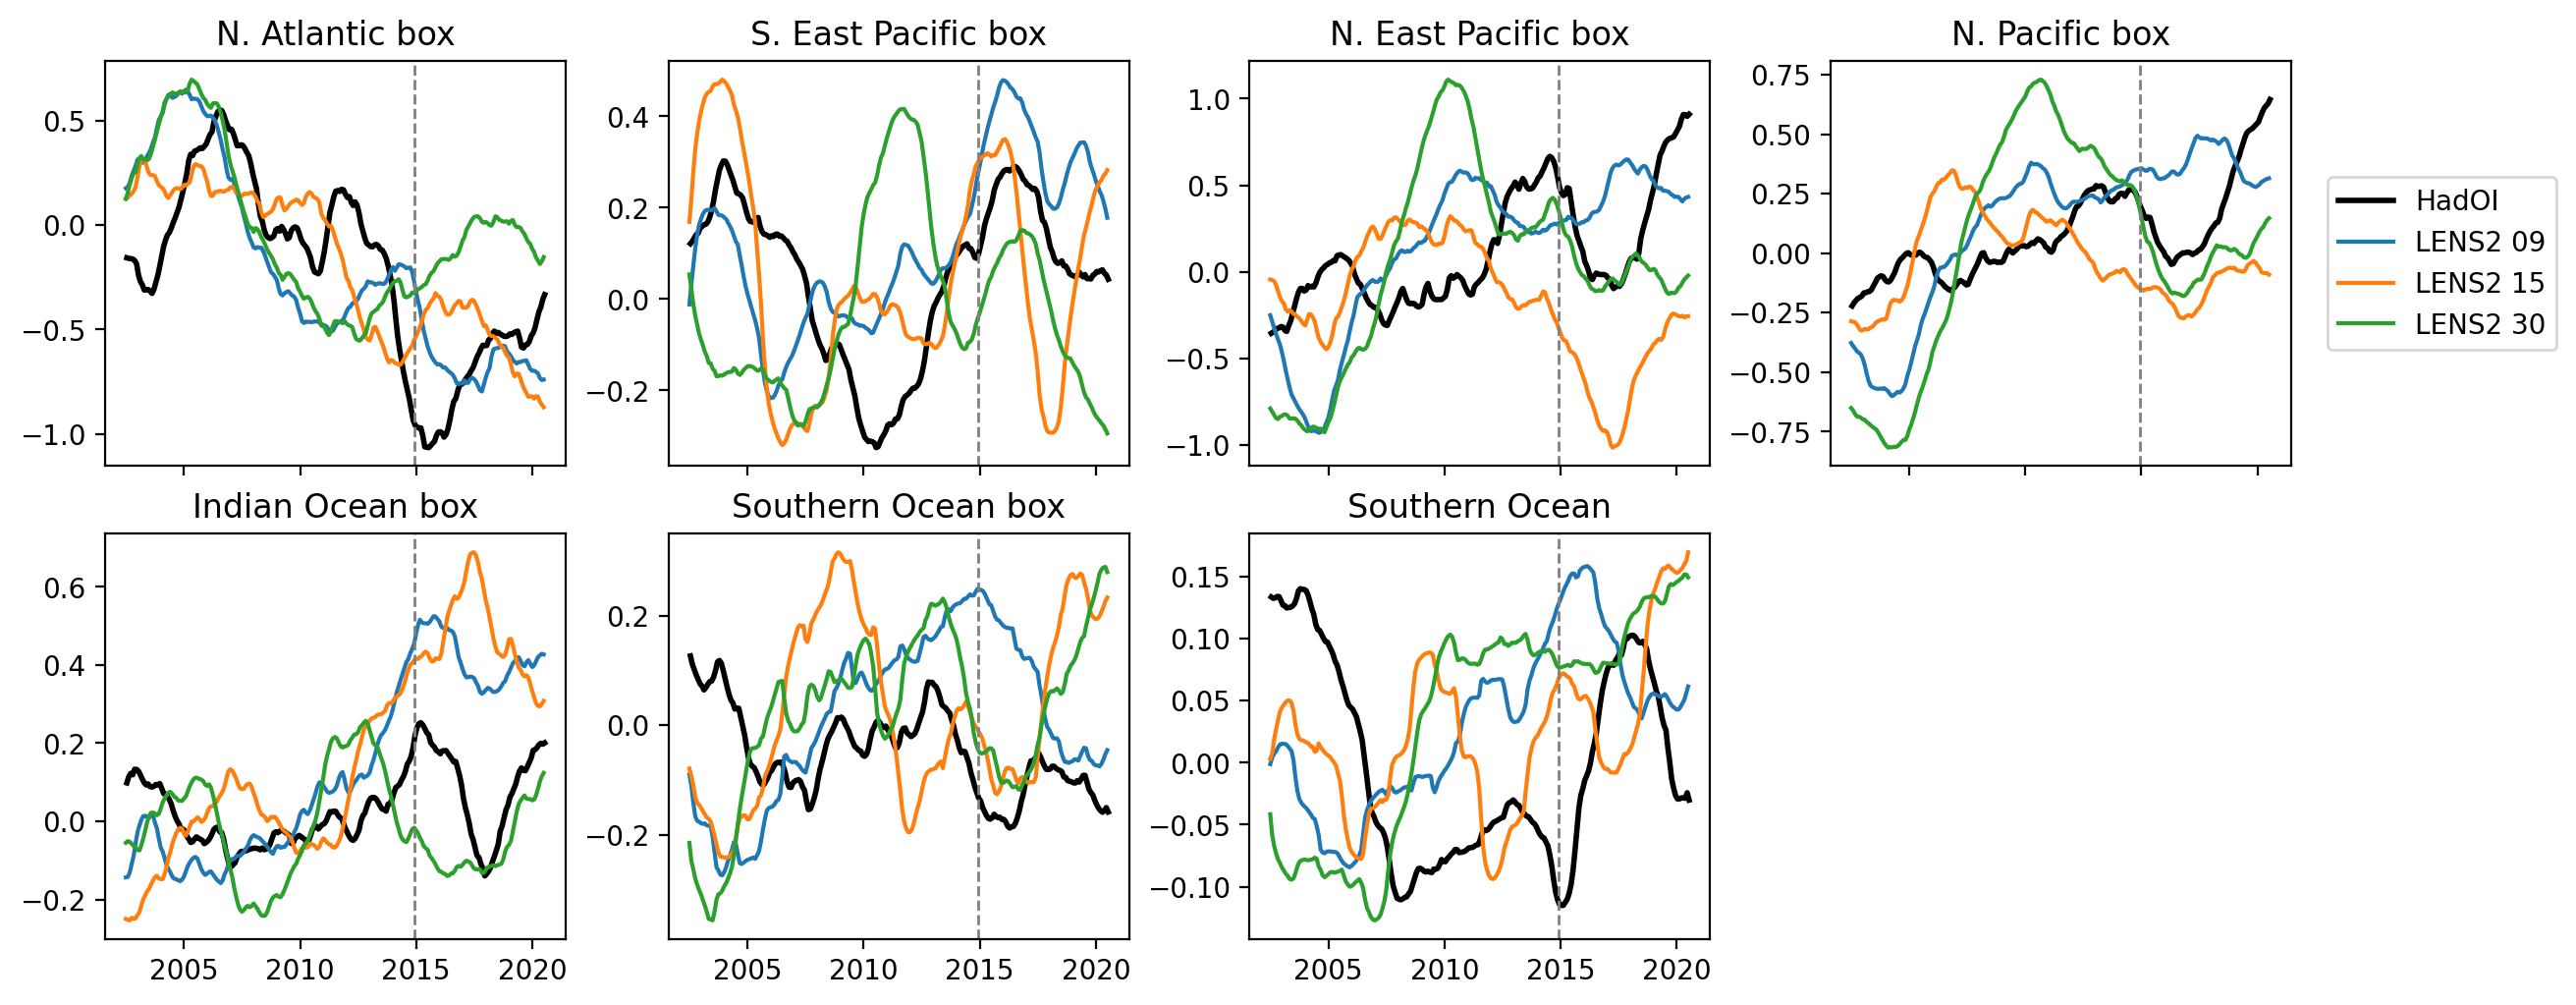

In [ ]:
smooth_months = 36
tperiod = slice('1995-01', '2021-12')

fig, axs = plt.subplots(2, 4, figsize=(13, 5), sharex=True, layout='constrained', dpi=200)
ax = axs.flatten()

obs_minus_clim = obs.groupby('time.month') - obs.sel(time=tperiod).groupby('time.month').mean()
lens_minus_clim = lens.groupby('time.month') - lens.sel(time=tperiod).groupby('time.month').mean()

for i, (name, reg) in enumerate(sst_regions.items()):
    obs_reg_roll = obs_minus_clim.where(reg).sel(time=tperiod).weighted(oa).mean(dim=['lat', 'lon']).rolling(time=smooth_months, center=True).mean().compute()
    lens_reg_roll = lens_minus_clim.sel(ens=candidates).sel(time=tperiod).where(reg).weighted(oa).mean(dim=['lat', 'lon']).rolling(time=smooth_months, center=True).mean().compute()

    obs_reg_ann = obs_minus_clim.where(reg).weighted(oa).mean(dim=['lat', 'lon']).groupby('time.year').mean().compute()
    lens_reg_ann = lens_minus_clim.sel(ens=candidates).where(reg).weighted(oa).mean(dim=['lat', 'lon']).groupby('time.year').mean().compute()

    obs_reg_roll.plot(ax=ax[i], c='k', ls='-', lw=2, label='HadOI')
    for ens in candidates:
        lens_reg_roll.sel(ens=ens).plot(ax=ax[i], ls='-', label=f'LENS2 {str(ens).zfill(2)}')
    ax[i].axvline(cftime.DatetimeGregorian(2014, 12, 1), color='gray', lw=1, ls='--')
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_title(sst_region_names[name])

    print(sst_region_names[name], 'annual stddev')
    print(f'  HadOI = {obs_reg_ann.std(dim='year').values: 0.3f}')
    for ens in candidates:
        print(f'  LENS{str(ens).zfill(2)} = {lens_reg_ann.sel(ens=ens).std(dim='year').values: 0.3f}')

ax[3].legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
ax[-1].remove()

In [126]:
def split_years_months(da):
    name = da.name
    years  = np.unique(da.time.dt.year.values)
    months = np.unique(da.time.dt.month.values)
    
    # Rechunk time dim contiguously before reshape
    da = da.chunk({'time': -1})
    
    new_shape = (len(years), len(months)) + da.shape[1:]
    new_dims  = ['year', 'month'] + list(da.dims[1:])
    
    extra_coords = {k: v for k, v in da.coords.items()
                    if 'time' not in v.dims}
    
    return xr.DataArray(
        da.data.reshape(new_shape),   # dask-safe
        dims=new_dims,
        coords={'year': years, 'month': months, **extra_coords}
    ).rename(name)


def combine_years_months(da, freq='MS'):
    name = da.name
    years  = da.year.values   # shape (Y,)
    months = da.month.values  # shape (M,)

    # Build full Y×M time index, then flatten
    yy, mm = np.meshgrid(years, months, indexing='ij')  # both (Y, M)
    time_index = xr.date_range(                         # or pd.date_range if using numpy datetimes
        start=f'{years[0]}-{months[0]:02d}',
        periods=len(years) * len(months),
        freq=freq,
        use_cftime=True
    )

    # Flatten year×month into time, preserve trailing spatial dims
    trailing_dims   = list(da.dims[2:])          # e.g. ['lat', 'lon']
    trailing_shape  = da.shape[2:]
    flat_data = da.data.reshape(len(time_index), *trailing_shape)  # dask-safe

    # Preserve non-(year,month) coords
    extra_coords = {k: v for k, v in da.coords.items()
                    if not any(d in ('year', 'month') for d in v.dims)}

    return xr.DataArray(
        flat_data,
        dims=['time'] + trailing_dims,
        coords={'time': time_index, **extra_coords}
    ).rename(name)


def detrend(da, tcoord):
    if not isinstance(da[tcoord][0].item(), float):
        dat = da.assign_coords(t=(tcoord, np.arange(len(da[tcoord]))))
        coeffs = dat.polyfit(dim='t', deg=1, skipna=True).polyfit_coefficients
        trend = coeffs.sel(degree=1) # per tcoord
        return da - trend * (dat['t'] - dat['t'][0])

    coeffs = da.polyfit(dim=tcoord, deg=1, skipna=True).polyfit_coefficients
    trend = coeffs.sel(degree=1) # per tcoord
    return da - trend * (da[tcoord] - da[tcoord][0])


def detrend_year(da):
    dam = split_years_months(da)
    dam_dt = detrend(dam, 'year')
    return combine_years_months(dam_dt)

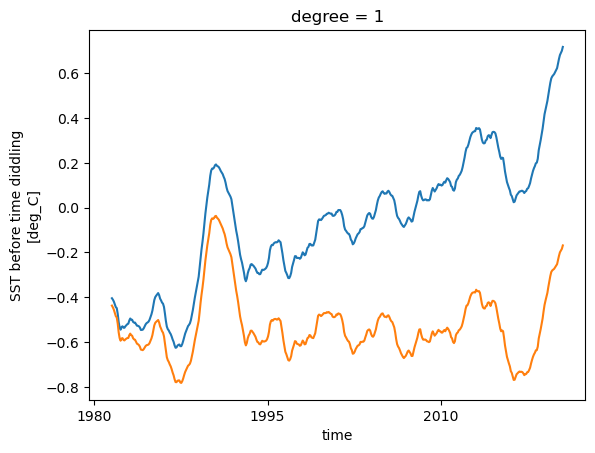

In [128]:
reg = sst_regions['npa']
da = obs_minus_clim.where(reg).weighted(oa).mean(dim=['lat', 'lon']).rolling(time=smooth_months, center=True).mean().compute()

da_dt = detrend(da, 'time')

da.plot()
da_dt.plot()

In [107]:
# client_cluster[0].restart()

In [2]:
# obs_minus_clim = obs.groupby('time.month') - obs.sel(time=clim_tperiod).groupby('time.month').mean()
# obs_minus_clim = obs_minus_clim.compute()
# obs_minus_clim_dt = detrend(obs_minus_clim, tcoord='time').compute()

# lens_minus_clim = lens.groupby('time.month') - lens.sel(time=clim_tperiod).groupby('time.month').mean()
# lens_minus_clim = lens_minus_clim.compute()
# lens_minus_clim = lens_minus_clim.transpose('time', 'lat', 'lon', 'ens')
# lens_minus_clim_dt = detrend(lens_minus_clim, tcoord='time').compute()

In [1]:
# smooth_months = 36
# clim_tperiod = slice('1995-01', '2015-01')

# fig, axs = plt.subplots(2, 4, figsize=(13, 5), sharex=True, layout='constrained', dpi=200)
# ax = axs.flatten()

# for i, (name, reg) in enumerate(sst_regions.items()):
#     obs_reg_roll = obs_minus_clim_dt.where(reg).weighted(oa).mean(dim=['lat', 'lon']).rolling(time=smooth_months, center=True).mean().compute()
#     lens_reg_roll = lens_minus_clim_dt.sel(ens=candidates).where(reg).weighted(oa).mean(dim=['lat', 'lon']).rolling(time=smooth_months, center=True).mean().compute()

#     # obs_reg_ann = obs_minus_clim_dt.where(reg).weighted(oa).mean(dim=['lat', 'lon']).groupby('time.year').mean().compute()
#     # lens_reg_ann = lens_minus_clim_dt.sel(ens=candidates).where(reg).weighted(oa).mean(dim=['lat', 'lon']).groupby('time.year').mean().compute()

#     obs_reg_roll.plot(ax=ax[i], c='k', ls='-', lw=2, label='HadOI')
#     for ens in candidates:
#         lens_reg_roll.sel(ens=ens).plot(ax=ax[i], ls='-', label=f'LENS2 {str(ens).zfill(2)}')
#     ax[i].axvline(cftime.DatetimeGregorian(2014, 12, 1), color='gray', lw=1, ls='--')
#     ax[i].set_ylabel('')
#     ax[i].set_xlabel('')
#     ax[i].set_title(sst_region_names[name])

#     # print(sst_region_names[name], 'annual stddev')
#     # print(f'  HadOI = {obs_reg_ann.std(dim='year').values: 0.3f}')
#     # for ens in candidates:
#     #     print(f'  LENS{str(ens).zfill(2)} = {lens_reg_ann.sel(ens=ens).std(dim='year').values: 0.3f}')

# ax[3].legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
# ax[-1].remove()